## <center><b> Statistical analysis

### <center> Normality testing

In [ ]:
import numpy as np
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import os

In [45]:
load_dotenv('vars.env')
DATA_PATH = os.getenv("DATA_PATH")


In [46]:
# Collect paths from patient records
patients = []
vital_base = os.path.join(DATA_PATH, 'Vital data')
hs_base    = os.path.join(DATA_PATH, 'HemoSphere data')

for folder in sorted(os.listdir(vital_base)):
    vital_pad = os.path.join(vital_base, folder, 'vital.csv')
    hs_pad    = os.path.join(hs_base,    folder, 'hemosphere.csv')

    if os.path.exists(vital_pad) and os.path.exists(hs_pad):
        patients.append((vital_pad, hs_pad))

print(f"N patients: {len(patients)}")
for v, h in patients:
    print(f"Vital: {v}, Hemosphere: {h}")
patient_ids = []
for vital_path, hs_path in patients:
    naam = os.path.basename(os.path.dirname(vital_path)) 
    patient_id = int(naam.replace('MARTINI_', ''))        
    patient_ids.append(patient_id)
print(f'Patiënt IDs: {patient_ids}')

df_demo = pd.read_csv(os.path.join(DATA_PATH, 'df_baseline.csv'),sep=';')
df_final = df_demo[df_demo['Participant Id'].isin(patient_ids)].copy()

N patients: 96
Vital: P:\Vital data\MARTINI_110002\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110002\hemosphere.csv
Vital: P:\Vital data\MARTINI_110003\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110003\hemosphere.csv
Vital: P:\Vital data\MARTINI_110006\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110006\hemosphere.csv
Vital: P:\Vital data\MARTINI_110007\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110007\hemosphere.csv
Vital: P:\Vital data\MARTINI_110008\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110008\hemosphere.csv
Vital: P:\Vital data\MARTINI_110009\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110009\hemosphere.csv
Vital: P:\Vital data\MARTINI_110011\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110011\hemosphere.csv
Vital: P:\Vital data\MARTINI_110015\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110015\hemosphere.csv
Vital: P:\Vital data\MARTINI_110016\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110016\hemosphere.csv
Vital: P:\Vit

### <center> Descriptive statistics


In [52]:
summary = []

# Continuous variables
for column, name, unit in [
    ('age_at_surgery', 'Age', 'years'),
    ('dem_height', 'Height', 'cm'),
    ('dem_weight', 'Weight', 'kg')
]:
    data = df_final[column].dropna()

    summary.append({
        'Characteristic': f'{name}, median (interquartile range), {unit}',
        'Validation': (
            f'{data.median():.1f} '
            f'({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
        )
    })

# Sex
sex = df_final['dem_sex'].map({'Male': 1, 'Female': 0})
n_total = sex.notna().sum()
n_male = (sex == 1).sum()
percent_male = 100 * n_male / n_total

summary.insert(1, {
    'Characteristic': 'Sex, number male (%)',
    'Validation': f'{n_male} ({100*n_male/n_total:.2f})'
})

column_name = f'Validation dataset (n={len(df_final)})'

df_summary = pd.DataFrame(summary)
df_summary.columns = ['Characteristic', column_name]

display(df_summary)



,Characteristic,Validation dataset (n=96)
0,"Age, median (interquartile range), years",67.0 (61.8-73.0)
1,"Sex, number male (%)",41 (42.71)
2,"Height, median (interquartile range), cm",174.0 (166.0-181.0)
3,"Weight, median (interquartile range), kg",75.5 (64.8-92.2)


### <center> Normality plots

In [50]:
def test_normal_distribution(data, name='data'):
    """
    Tests normality in four different ways:
    1. Shapiro-Wilk test
    2. Q-Q plot
    3. Histogram with normal curve
    4. Box plot
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats

    # Remove missing values and flatten
    data = np.array(data)
    data = data[~np.isnan(data)].flatten()

    # ── 1. Shapiro-Wilk test ─────────────────────────────────────────
    # Shapiro-Wilk performs best on a maximum of 5000 samples
    if len(data) > 5000:
        sample = np.random.choice(data, 5000, replace=False)
    else:
        sample = data

    stat, p_value = stats.shapiro(sample)

    print(f'\n── Shapiro-Wilk test: {name} ──')
    print(f'  Statistic: {stat:.4f}')
    print(f'  P-value:   {p_value:.4f}')

    if p_value > 0.05:
        print('  Conclusion: Normally distributed (p > 0.05)')
    else:
        print('  Conclusion: Not normally distributed (p < 0.05)')

    # ── Plots ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Normality Test - {name}', fontsize=13, fontweight='bold')

    # ── 2. Q-Q plot ─────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')

    axes[0].plot(
        osm,
        osr,
        'o',
        color='#378ADD',
        markersize=3,
        alpha=0.5
    )

    axes[0].plot(
        osm,
        slope * np.array(osm) + intercept,
        'r-',
        linewidth=1.5
    )

    axes[0].set_title('Q-Q Plot', fontweight='bold', loc='left')
    axes[0].set_xlabel('Theoretical Quantiles')
    axes[0].set_ylabel('Sample Quantiles')
    axes[0].grid(True, alpha=0.2)

    axes[0].text(
        0.05,
        0.95,
        f'R² = {r**2:.4f}',
        transform=axes[0].transAxes,
        fontsize=10,
        verticalalignment='top'
    )

    # ── 3. Histogram ──────────────────────────────────
    axes[1].hist(
        data,
        bins=40,
        color='#85B7EB',
        edgecolor='white',
        linewidth=0.5,
        density=True,
        alpha=0.8
    )

    x = np.linspace(data.min(), data.max(), 200)

    axes[1].plot(
        x,
        stats.norm.pdf(x, data.mean(), data.std()),
        'r-',
        linewidth=2,
        label='Normal Curve'
    )

    axes[1].set_title('Histogram', fontweight='bold', loc='left')
    axes[1].set_xlabel(name)
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    axes[1].text(
        0.05,
        0.95,
        f'p = {p_value:.4f}',
        transform=axes[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        color='green' if p_value < 0.05 else 'red'
    )

    # ── 4. Boxplot ──────────────────────────────────────────────────────
    axes[2].boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#85B7EB'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor='#378ADD',
            alpha=0.5
        )
    )

    axes[2].set_title('Box Plot', fontweight='bold', loc='left')
    axes[2].set_ylabel(name)
    axes[2].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    return stat, p_value


── Shapiro-Wilk test: Age (years) ──
  Statistic: 0.9681
  P-value:   0.0192
  Conclusion: Not normally distributed (p < 0.05)


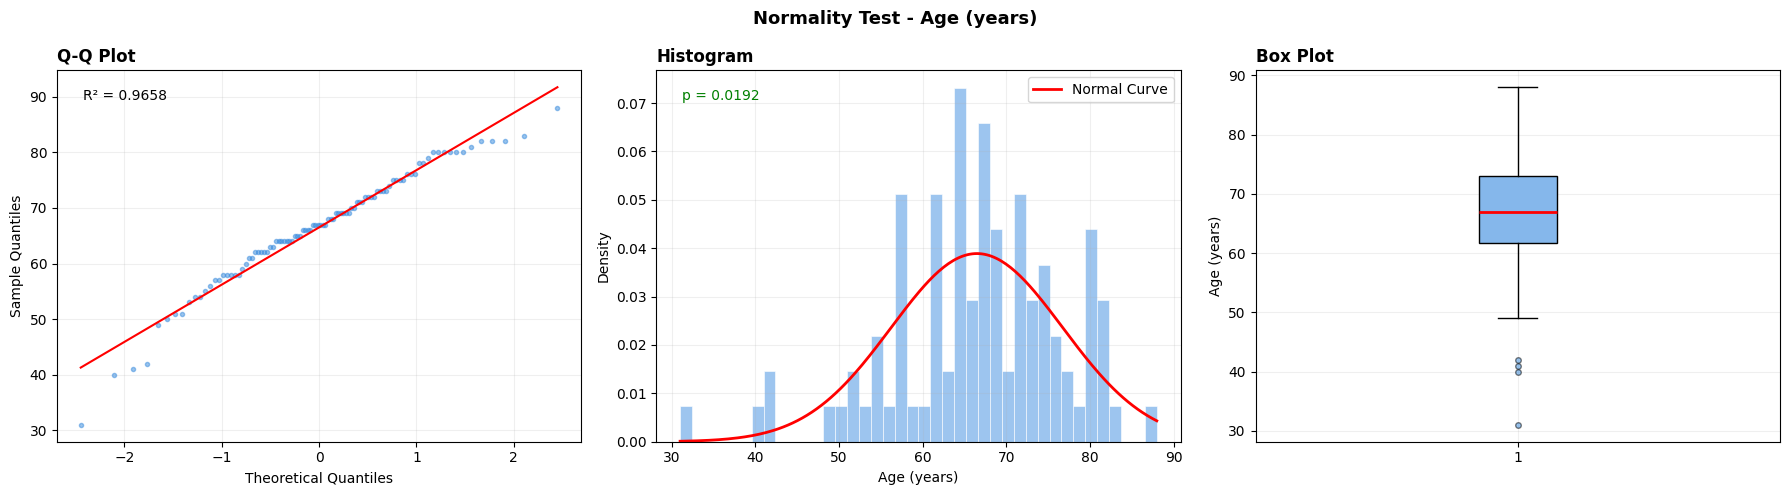


── Shapiro-Wilk test: Length (cm) ──
  Statistic: 0.9858
  P-value:   0.3924
  Conclusion: Normally distributed (p > 0.05)


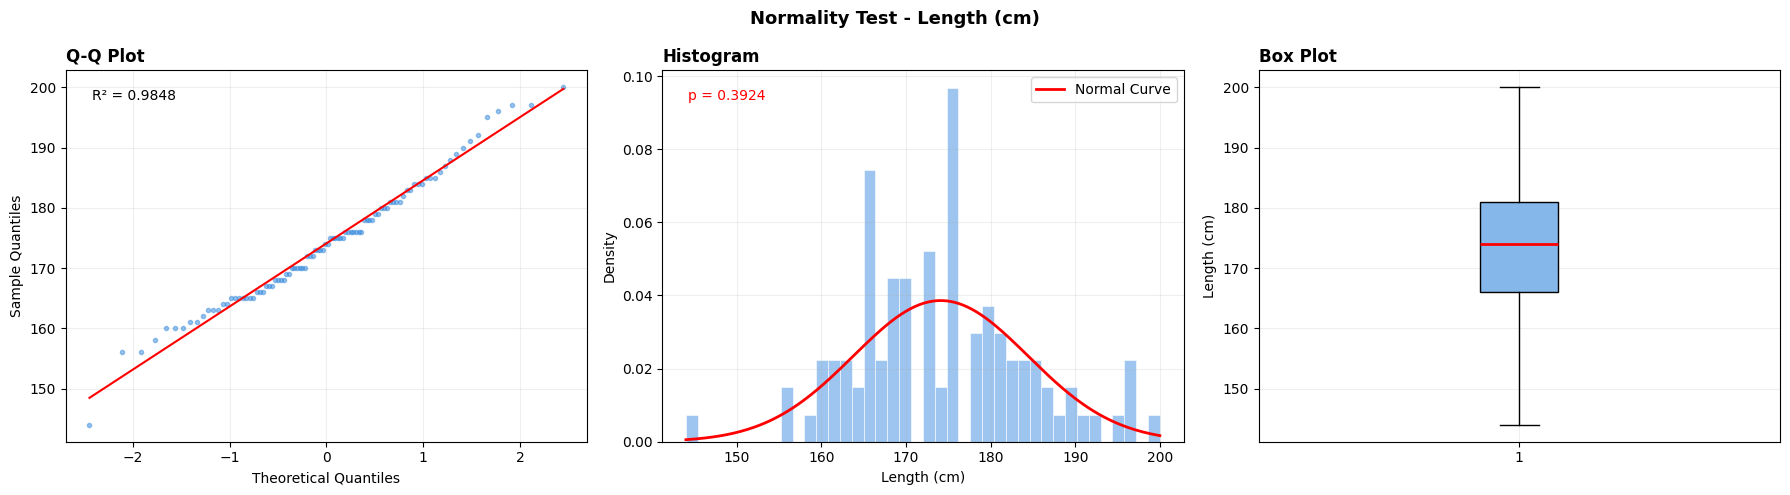


── Shapiro-Wilk test: Weight (kg) ──
  Statistic: 0.9568
  P-value:   0.0031
  Conclusion: Not normally distributed (p < 0.05)


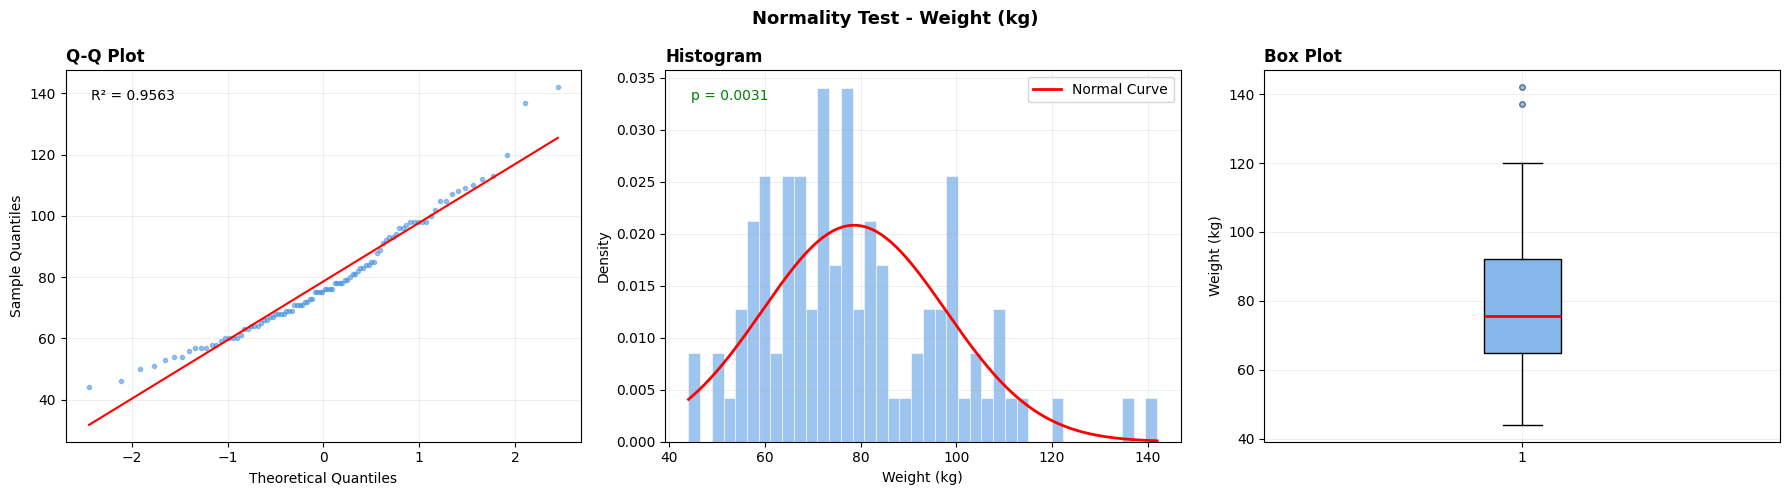

(np.float64(0.9567804037254942), np.float64(0.003068184686231707))

In [51]:
test_normal_distribution(df_final['age_at_surgery'].dropna().values, name='Age (years)')
test_normal_distribution(df_final['dem_height'].dropna().values,     name='Length (cm)')
test_normal_distribution(df_final['dem_weight'].dropna().values,     name='Weight (kg)')